# Why Are Customers Churning?
## An Exploratory Data Analysis with Business Insights and Retention Strategies


## Business Context
Customer churn is a major business challenge for telecom companies because losing customers reduces recurring revenue and increases customer acquisition cost.

This project analyzes customer behavior to identify the key drivers of churn and uncover high-risk customer segments. The goal is to translate data patterns into actionable retention strategies.

## Business Problem

The telecom industry faces strong competition, and customers can switch providers easily. Understanding why customers leave is essential for improving retention and protecting revenue.

This analysis focuses on answering the following questions:
- Which customers are most likely to churn?
- Which service and contract patterns are associated with churn?
- What business actions can help improve retention?

## Objective of the Analysis

The objective of this project is to analyze customer churn behavior and identify the most important factors influencing retention.

The analysis aims to:
- understand customer demographics and service usage
- study the relationship between contract type, payment behavior, and churn
- identify high-risk customer segments
- provide business recommendations to reduce churn

## Tools and Skills Used
### Libraries Used
- Pandas for data cleaning and analysis
- Matplotlib and Seaborn for visualization
- NumPy for numerical support
- os for file handling during data import

### Skills Demonstrated
- Data cleaning
- Exploratory data analysis
- Data visualization
- Correlation analysis
- Customer segmentation
- Business insight generation
- Retention strategy thinking

## Dataset Overview

The dataset contains customer-level information including demographics, service subscriptions, contract type, payment method, monthly charges, total charges, tenure, and churn status.

Each row represents one customer, and the target variable is churn, which indicates whether the customer left the service or remained active.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [64]:
os.getcwd()

'/content'

In [65]:
os.listdir()

['.config', 'Telco-Customer-Churn.csv', 'sample_data']

In [66]:
df = pd.read_csv("Telco-Customer-Churn.csv")

## Data Understanding
Before analyzing churn patterns, the dataset was explored to understand its structure, column types, statistical summary, and unique categories.

In [67]:
#first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [68]:
#last 5 rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [69]:
#random 5 rows
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6139,3039-MJSLN,Male,0,No,Yes,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.20,50.6,No
797,6286-ZHAOK,Female,0,Yes,Yes,20,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.55,507.4,No
2245,6050-FFXES,Female,0,Yes,No,69,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),105.35,7240.65,No
5140,7577-SWIFR,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.25,89.25,No
4955,5884-GCYMI,Male,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Mailed check,69.40,69.4,Yes


In [70]:
#Total rows & columns
df.shape

(7043, 21)

In [71]:
#all column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
#extreme paying maximum to minimum
df.sort_values(by='MonthlyCharges', ascending=False)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4586,7569-NMZYQ,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),118.75,8672.45,No
2115,8984-HPEMB,Female,0,No,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.65,8477.6,No
4804,5734-EJKXG,Female,0,No,No,61,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,118.60,7365.7,No
3894,5989-AXPUC,Female,0,Yes,No,68,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,118.60,7990.05,No
5127,8199-ZLLSA,Male,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),118.35,7804.15,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,0621-CXBKL,Female,0,No,No,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,18.70,1005.7,No
6906,9945-PSVIP,Female,0,Yes,Yes,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,18.70,383.65,No
6652,0827-ITJPH,Male,0,No,No,36,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),18.55,689,No
1529,9764-REAFF,Female,0,Yes,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),18.40,1057.85,No


## Data Cleaning
Data cleaning was required to ensure that the dataset was accurate and consistent before analysis.

### Cleaning Steps
- Identified that `TotalCharges` was stored as an object instead of a numeric column
- Converted `TotalCharges` to numeric using `pd.to_numeric(..., errors='coerce')
- Checked for missing values`
- Removed rows with missing values after conversion

In [74]:
df['TotalCharges'].dtype

dtype('O')

In [75]:
df['TotalCharges'] == " "

,TotalCharges
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [76]:
#column converted to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [77]:
df['TotalCharges'].dtype

dtype('float64')

In [78]:
#checking missing values in each column
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [79]:
#removing missing rows
df = df.dropna()

### Why Rows Were Removed Instead of Imputed
Only 11 rows out of 7043 contained missing values after the `TotalCharges` conversion, which is a very small percentage of the dataset. Because the missing proportion was negligible, removing those rows was the cleanest option and avoided introducing artificial values through imputation. If a larger portion of the data had been missing, imputation would have been considered.

In [80]:
#checking duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

# 📊 Statistical and Categorical Exploration

Both numerical and categorical features were explored to understand customer distribution patterns and business characteristics.

The analysis included:
- statistical summaries of numerical variables
- category frequency distributions
- churn distribution analysis
- customer demographic and service behavior patterns

In [82]:
#statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [83]:
#distributional summary of categorical columns
df.describe(include='object')
#describe() ALWAYS tries to show a “top” value—even if all values are equally frequent
#customerID is a unique identifier, so the ‘top’ value is arbitrary and not useful for analysis

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


## Categorical Feature Exploration

In [84]:
df.nunique()

,0
customerID,7032
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [85]:
#to see actual categories
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [86]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [87]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26, 39])

In [88]:
sorted(df['tenure'].unique())


[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.int64(67),
 np.

In [89]:
df['OnlineBackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [90]:
#value_counts() tells "How many times each category appears"
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [91]:
#converting count into %
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [92]:
df['gender'].value_counts()

,count
gender,
Male,3549
Female,3483


In [93]:
df['gender'].value_counts(normalize=True) * 100

,proportion
gender,
Male,50.469283
Female,49.530717


### Contract Distribution

In [94]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1685
One year,1472


In [95]:
df['Contract'].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.105233
Two year,23.961889
One year,20.932878


### Payment Method Distribution

In [96]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


### Internet Service Distribution

In [97]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2416
No,1520


In [98]:
df.groupby('Contract')['Churn'].value_counts()


Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1306
                Yes       166
Two year        No       1637
                Yes        48
Name: count, dtype: int64

### Key Insights

Customers with month-to-month contracts show the highest churn (~43%) compared to one-year (~11%) and two-year contracts (~3%), suggesting that longer contract durations improve customer retention.

### Business Recommendation

Promote long-term plans through discounts, bundled offers, and loyalty incentives to reduce churn and improve retention.

In [99]:
df.groupby('PaymentMethod')['Churn'].value_counts()

PaymentMethod              Churn
Bank transfer (automatic)  No       1284
                           Yes       258
Credit card (automatic)    No       1289
                           Yes       232
Electronic check           No       1294
                           Yes      1071
Mailed check               No       1296
                           Yes       308
Name: count, dtype: int64

In [100]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)

PaymentMethod              Churn
Bank transfer (automatic)  No       0.832685
                           Yes      0.167315
Credit card (automatic)    No       0.847469
                           Yes      0.152531
Electronic check           No       0.547146
                           Yes      0.452854
Mailed check               No       0.807980
                           Yes      0.192020
Name: proportion, dtype: float64

### Key Insights

Customers using electronic check payment methods show the highest churn (approx 45%) compared to customers using automatic payment methods such as credit cards and bank transfers (~15–20%), indicating that payment behavior influences customer retention.

### Business Recommendation

Encourage customers to adopt automatic payment methods through incentives, cashback offers, or simplified auto-pay enrollment to improve retention.

In [101]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)

InternetService  Churn
DSL              No       0.810017
                 Yes      0.189983
Fiber optic      No       0.581072
                 Yes      0.418928
No               No       0.925658
                 Yes      0.074342
Name: proportion, dtype: float64

### Key Insights

Customers using fiber optic internet services show significantly higher churn ( approx 42%) compared to DSL users ( approx 19%) and customers without internet services (~7%), suggesting potential concerns related to pricing, service expectations, or customer satisfaction.

### Business Recommendation

mprove retention among fiber optic customers through better service quality, targeted offers, loyalty benefits, and enhanced customer support to reduce churn among high-value users.

In [102]:
#combination effect (multiple variable insights)
df.groupby(['Contract','PaymentMethod'])['Churn'].value_counts(normalize=True)

Contract        PaymentMethod              Churn
Month-to-month  Bank transfer (automatic)  No       0.658744
                                           Yes      0.341256
                Credit card (automatic)    No       0.672192
                                           Yes      0.327808
                Electronic check           Yes      0.537297
                                           No       0.462703
                Mailed check               No       0.684211
                                           Yes      0.315789
One year        Bank transfer (automatic)  No       0.902813
                                           Yes      0.097187
                Credit card (automatic)    No       0.896985
                                           Yes      0.103015
                Electronic check           No       0.815562
                                           Yes      0.184438
                Mailed check               No       0.931548
                                           Yes      0.068452
Two year        Bank transfer (automatic)  No       0.966192
                                           Yes      0.033808
                Credit card (automatic)    No       0.977586
                                           Yes      0.022414
                Electronic check           No       0.922619
                                           Yes      0.077381
                Mailed check               No       0.992000
                                           Yes      0.008000
Name: proportion, dtype: float64

### Key Insight

Customers on **month-to-month contracts using electronic check payments** show the highest churn (~54%), making them the most vulnerable customer segment.

## Business Recommendation

Target this high-risk group with **retention offers, auto-pay incentives, and long-term contract benefits** to reduce churn risk.


In [103]:
df.groupby(['Contract','PaymentMethod','InternetService'])['Churn'].value_counts(normalize=True)

Contract        PaymentMethod              InternetService  Churn
Month-to-month  Bank transfer (automatic)  DSL              No       0.802030
                                                            Yes      0.197970
                                           Fiber optic      No       0.544343
                                                            Yes      0.455657
                                           No               No       0.800000
                                                                       ...   
Two year        Mailed check               DSL              No       1.000000
                                           Fiber optic      No       0.952381
                                                            Yes      0.047619
                                           No               No       0.991903
                                                            Yes      0.008097
Name: proportion, Length: 70, dtype: float64

## Exploratory Data Analysis
The following visualizations were used to understand churn patterns across customer groups and identify high-risk segments.

In [104]:
sns.set_style("whitegrid")   # makes plots clean automatically

### Churn Distribution Analysis

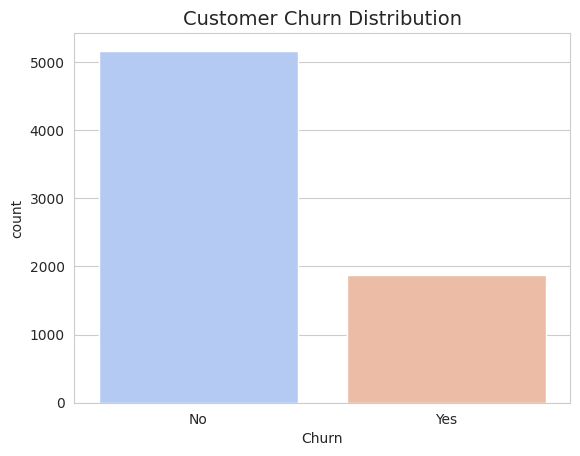

In [105]:
sns.countplot(x='Churn', data=df, hue='Churn', palette='coolwarm', legend=False)
plt.title("Customer Churn Distribution", fontsize=14)
plt.show()

#### Key Insights
- Most customers are retained, but churn is still significant.
- The dataset shows moderate class imbalance.
- Churn is a meaningful business problem and requires attention.

### Contract Type vs Churn

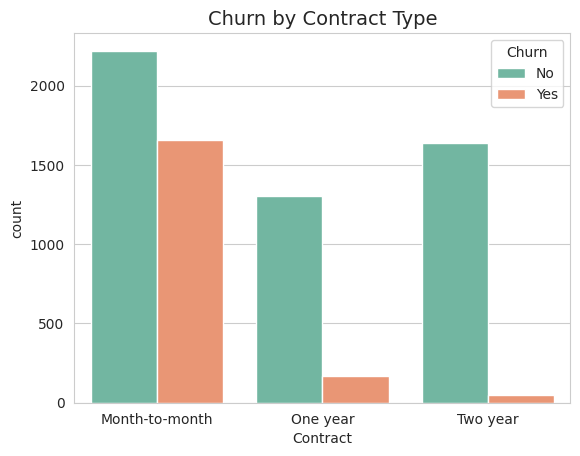

In [106]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title("Churn by Contract Type", fontsize = 14)
plt.show()

#### Key Insights
- Month-to-month contracts have the highest churn.
- One-year and two-year contracts show much better retention.
- Contract duration is one of the strongest churn drivers.

### Payment Method vs Churn

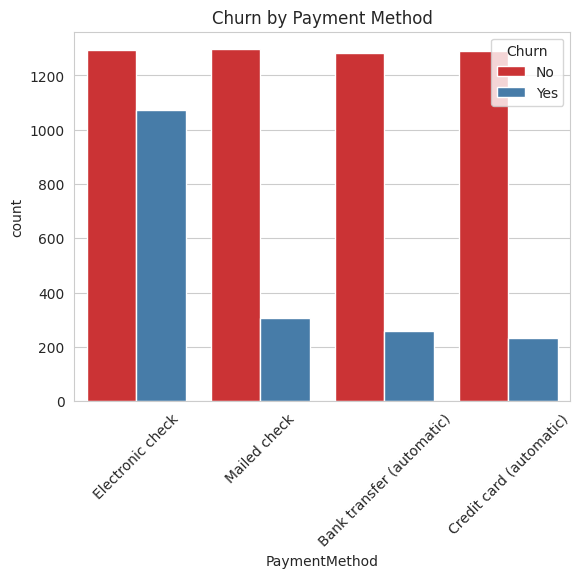

In [107]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df, palette='Set1')
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

#### Key Insights
- Electronic check users have the highest churn.
- Automatic payment users show better retention.
- Payment convenience appears to influence customer loyalty.

### Internet Service vs Churn

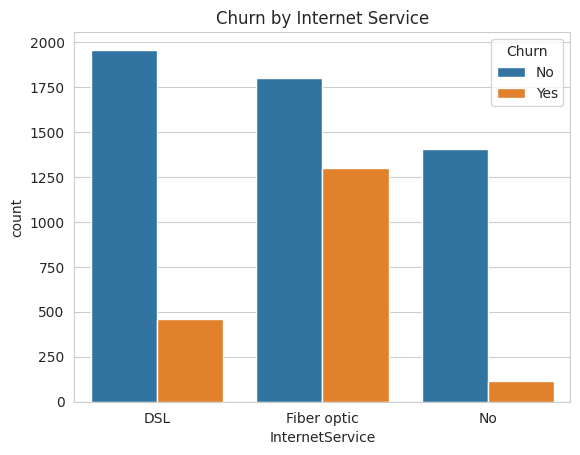

In [108]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()

#### Key Insights
- Fiber optic customers show the highest churn.
- Fiber optic users are a high-value but high-risk group.
- Customers without internet service show very low churn.

### Monthly Charges vs Churn

/tmp/ipykernel_8654/2579694328.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='pastel')


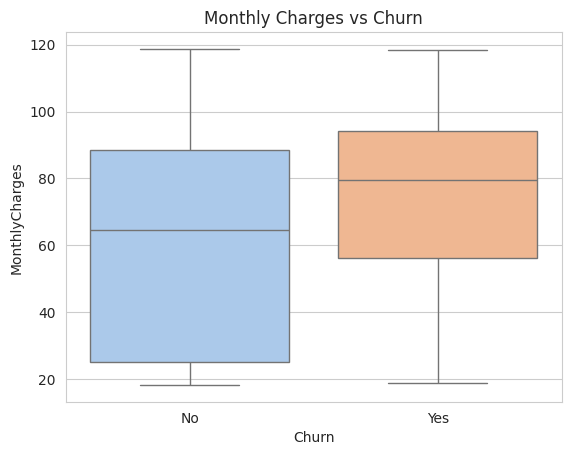

In [109]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='pastel')
plt.title("Monthly Charges vs Churn")
plt.show()

#### Key Insights
- Customers with higher monthly charges tend to churn more.
- Pricing sensitivity appears to play an important role in retention.
- Premium customers should be monitored closely.

###Internet vs MonthlyCharges


/tmp/ipykernel_8654/226211531.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='InternetService', y='MonthlyCharges', data=df, palette='Set3')


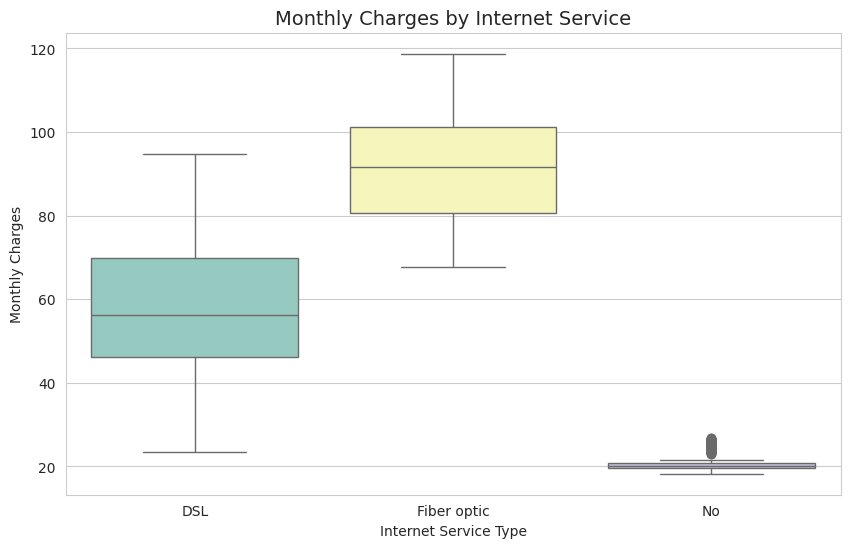

In [110]:
plt.figure(figsize=(10,6))
sns.boxplot(x='InternetService', y='MonthlyCharges', data=df, palette='Set3')
plt.title("Monthly Charges by Internet Service", fontsize=14)
plt.xlabel("Internet Service Type")
plt.ylabel("Monthly Charges")
plt.show()

### Tenure vs Churn

/tmp/ipykernel_8654/374379932.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='cool')


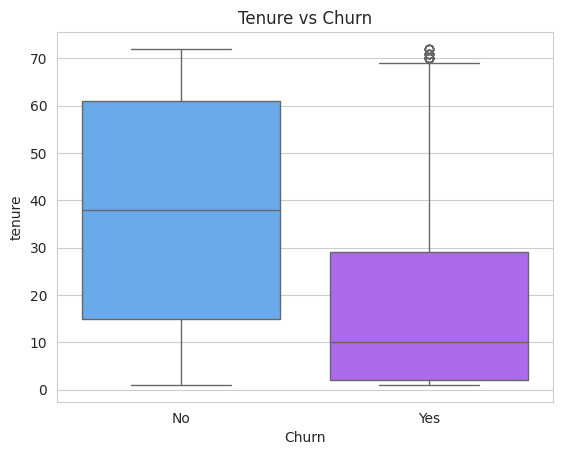

In [111]:
sns.boxplot(x='Churn', y='tenure', data=df, palette='cool')
plt.title("Tenure vs Churn")
plt.show()

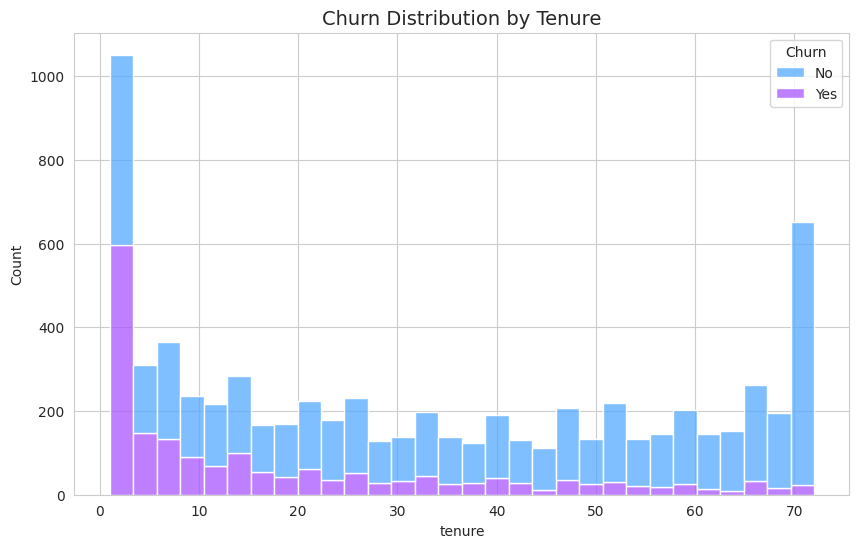

In [112]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='stack',
    palette='cool',
    bins=30
)

plt.title("Churn Distribution by Tenure", fontsize=14)
plt.show()

#### Key Insights
- Customers with low tenure churn more frequently.
- Long-term customers are more stable.
- The early months of the customer lifecycle are the most critical for retention.

### Correlation Analysis

In [113]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


#### Key Insights
- Tenure and TotalCharges show a strong positive correlation.
- MonthlyCharges is moderately related to TotalCharges.
- Correlation shows numerical relationships, but not necessarily business importance.

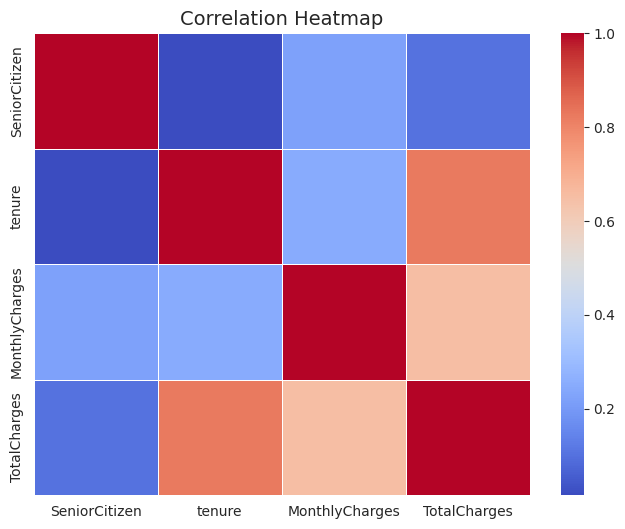

In [114]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

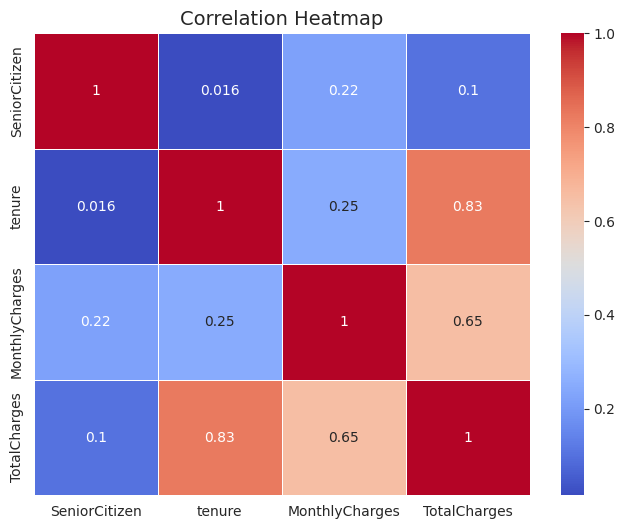

In [115]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

## High-Risk Customer Segment Analysis

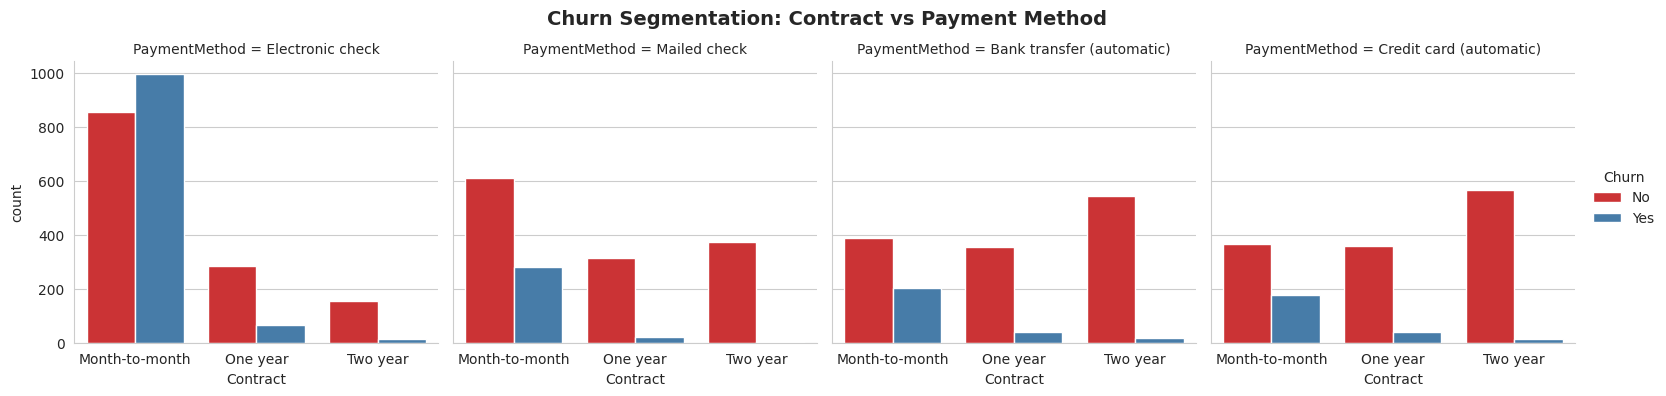

In [116]:
sns.catplot(
    x='Contract',
    hue='Churn',
    col='PaymentMethod',
    data=df,
    kind='count',
    height=4,
    aspect=1,
    palette='Set1'
)

plt.subplots_adjust(top=0.85)
plt.suptitle("Churn Segmentation: Contract vs Payment Method", fontsize=14, fontweight='bold')

plt.show()

## Key Insight

Customers using **electronic check with month-to-month contracts** show the highest churn, while **long-term contracts and automatic payment methods** are associated with stronger retention.

## Business Recommendation

Encourage customers to adopt **long-term plans and auto-pay methods** through targeted incentives to reduce churn risk.


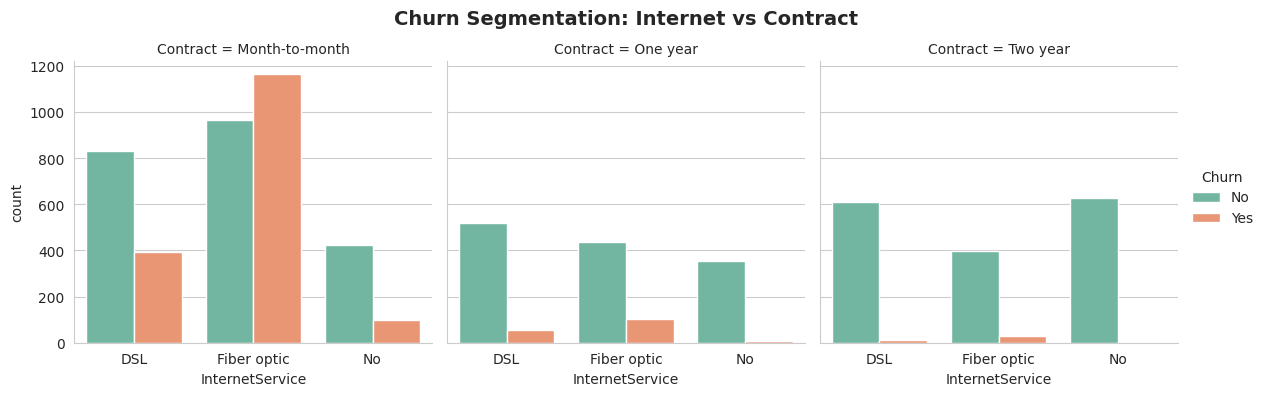

In [55]:
sns.catplot(
    x='InternetService',
    hue='Churn',
    col='Contract',
    data=df,
    kind='count',
    height=4,
    aspect=1,
    palette='Set2'
)

plt.subplots_adjust(top=0.85)
plt.suptitle("Churn Segmentation: Internet vs Contract", fontsize=14, fontweight='bold')

plt.show()

## Key Insight

Customers using **fiber optic internet with month-to-month contracts** show the highest churn, while **long-term contracts** are associated with significantly lower churn across all service types.

## Business Recommendation

Prioritize **fiber optic customers on flexible contracts** through targeted retention offers, improved service quality, and loyalty incentives.


# Inferential Statistics

## Confidence Interval Analysis

In [56]:
from statsmodels.stats.proportion import proportion_confint

# churn count
churn_count = df[df['Churn'] == 'Yes'].shape[0]

# total customers
total_customers = df.shape[0]

# confidence interval
low, high = proportion_confint(
    churn_count,
    total_customers,
    alpha=0.05,
    method='normal'
)

print("95% Confidence Interval:")
print(f"{low:.3f} to {high:.3f}")

95% Confidence Interval:
0.255 to 0.276



### Key Insight

At a **95% confidence level**, the estimated churn rate lies between **25.5% and 27.6%**, indicating a statistically reliable estimate of customer churn.

### Business Interpretation

The churn rate remains substantial, highlighting customer retention as an important business concern.


## Margin of Error

In [57]:
# sample churn proportion
p = churn_count / total_customers

# z-score for 95% confidence
z = 1.96

# margin of error
moe = z * np.sqrt((p * (1 - p)) / total_customers)

print(f"Margin of Error: ±{moe:.3f}")

Margin of Error: ±0.010




### Key Insight

The estimated churn rate has a **margin of error of ±1.0%**, suggesting that the churn estimate is reasonably reliable for business analysis.

## Z-Test: Senior Citizens vs Non-Senior Citizens Churn Analysis

### Business Question
Does customer churn behavior significantly differ between senior citizens and non-senior citizens?

### Hypotheses
- Null Hypothesis (H₀): There is no significant difference in churn rates between senior citizens and non-senior citizens.
- Alternative Hypothesis (H₁): There is a significant difference in churn rates between senior citizens and non-senior citizens.

In [58]:
from statsmodels.stats.proportion import proportions_ztest

# churned senior citizens
senior_churn = df[(df['SeniorCitizen'] == 1) & (df['Churn'] == 'Yes')].shape[0]

# total senior citizens
senior_total = df[df['SeniorCitizen'] == 1].shape[0]

# churned non-senior citizens
non_senior_churn = df[(df['SeniorCitizen'] == 0) & (df['Churn'] == 'Yes')].shape[0]

# total non-senior citizens
non_senior_total = df[df['SeniorCitizen'] == 0].shape[0]

# counts and observations
count = [senior_churn, non_senior_churn]
nobs = [senior_total, non_senior_total]

# perform z-test
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-Statistic:", round(z_stat, 3))
print("P-Value:", round(p_value, 5))

Z-Statistic: 12.624
P-Value: 0.0


### Interpretation

Since the p-value < 0.05, the null hypothesis is rejected. Customer churn differs significantly between senior citizens and non-senior citizens, indicating that age group may influence retention behavior.

## Z-Test: Monthly Charges vs Customer Churn

### Business Question
Does customer churn behavior significantly differ between customers with high monthly charges and low monthly charges?

### Hypotheses
- Null Hypothesis (H₀): There is no significant difference in churn rates between high-charge and low-charge customers.
- Alternative Hypothesis (H₁): There is a significant difference in churn rates between high-charge and low-charge customers.

In [59]:
from statsmodels.stats.proportion import proportions_ztest

# median monthly charge
median_charge = df['MonthlyCharges'].median()

# high-charge churned customers
high_churn = df[(df['MonthlyCharges'] > median_charge) & (df['Churn'] == 'Yes')].shape[0]

# total high-charge customers
high_total = df[df['MonthlyCharges'] > median_charge].shape[0]

# low-charge churned customers
low_churn = df[(df['MonthlyCharges'] <= median_charge) & (df['Churn'] == 'Yes')].shape[0]

# total low-charge customers
low_total = df[df['MonthlyCharges'] <= median_charge].shape[0]

# counts and observations
count = [high_churn, low_churn]
nobs = [high_total, low_total]

# perform z-test
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-Statistic:", round(z_stat, 3))
print("P-Value:", round(p_value, 5))

Z-Statistic: 16.375
P-Value: 0.0


### Interpretation

Since the p-value < 0.05, the null hypothesis is rejected. Customers with higher monthly charges exhibit significantly different churn behavior, suggesting pricing may influence retention.

## Chi-Square Test: Contract Type vs Customer Churn

### Business Question
Is there a significant relationship between customer contract type and churn behavior?

### Hypotheses
- Null Hypothesis (H₀): Contract type and customer churn are independent.
- Alternative Hypothesis (H₁): Contract type and customer churn are significantly associated.

In [60]:
from scipy.stats import chi2_contingency
import pandas as pd

# contingency table
contract_churn_table = pd.crosstab(df['Contract'], df['Churn'])

# chi-square test
chi2, p_value, dof, expected = chi2_contingency(contract_churn_table)

print("Chi-Square Statistic:", round(chi2, 3))
print("P-Value:", round(p_value, 5))

Chi-Square Statistic: 1179.546
P-Value: 0.0


### Interpretation

Since the p-value < 0.05, the null hypothesis is rejected. Contract type significantly influences churn, with month-to-month customers showing higher attrition than long-term contract customers.

## Chi-Square Test: Payment Method vs Customer Churn

### Business Question
Is there a significant relationship between payment method and customer churn behavior?

### Hypotheses
- Null Hypothesis (H₀): Payment method and customer churn are independent.
- Alternative Hypothesis (H₁): Payment method and customer churn are significantly associated.

In [61]:
# contingency table
payment_churn_table = pd.crosstab(df['PaymentMethod'], df['Churn'])

# chi-square test
chi2, p_value, dof, expected = chi2_contingency(payment_churn_table)

print("Chi-Square Statistic:", round(chi2, 3))
print("P-Value:", round(p_value, 5))

Chi-Square Statistic: 645.43
P-Value: 0.0


### Interpretation

Since the p-value < 0.05, the null hypothesis is rejected. Customers using electronic check payments show higher churn, indicating payment behavior may influence retention.

## Chi-Square Test: Internet Service vs Customer Churn

### Business Question
Is there a significant relationship between internet service type and customer churn behavior?

### Hypotheses
- Null Hypothesis (H₀): Internet service type and customer churn are independent.
- Alternative Hypothesis (H₁): Internet service type and customer churn are significantly associated.

In [62]:
# contingency table
internet_churn_table = pd.crosstab(df['InternetService'], df['Churn'])

# chi-square test
chi2, p_value, dof, expected = chi2_contingency(internet_churn_table)

print("Chi-Square Statistic:", round(chi2, 3))
print("P-Value:", round(p_value, 5))

Chi-Square Statistic: 728.696
P-Value: 0.0


### Interpretation

Since the p-value < 0.05, the null hypothesis is rejected. Internet service type is significantly associated with customer churn, with fiber optic customers showing higher churn compared to DSL and non-internet users.


## Executive Insights

Customer churn is primarily influenced by **contract type, payment behavior, internet service, tenure, and pricing**.

### Key Findings

* **Month-to-month customers** represent the highest churn-risk segment.
* **Electronic check users** show higher churn than auto-pay customers.
* **Fiber optic customers** are high-value but more vulnerable to churn.
* **Higher monthly charges** are associated with increased churn risk.
* **Churn is highest during the early customer lifecycle**.


## Business Impact of Churn Reduction

Reducing customer churn is essential for improving **customer retention, recurring revenue, and long-term profitability**. Since retaining existing customers is more cost-effective than acquiring new ones, effective churn reduction strategies can increase **customer lifetime value** while lowering acquisition costs.


## Retention Strategies & Business Recommendations



### 1. Strengthen Long-Term Contract Adoption

**Key Finding:** Customers on **month-to-month contracts** show the highest churn, while long-term contracts are associated with stronger retention.

**Recommended Actions:**

* Promote **yearly and two-year plans** through discounts and bundled offers
* Introduce **loyalty rewards and renewal incentives**
* Encourage contract upgrades for high-risk customers

Strengthening long-term contract adoption can improve customer retention and create more stable recurring revenue.


### 2. Improve Fiber Optic Customer Retention

**Key Finding:** **Fiber optic customers** are high-value users but exhibit higher churn.

**Recommended Actions:**

* Improve **service quality and technical support**
* Offer **targeted retention packages and loyalty benefits**
* Monitor customer satisfaction proactively

Improving retention among fiber optic customers can reduce revenue loss from high-value customer churn.

### 3. Promote Automatic Payment Methods

**Key Finding:** Customers using **electronic check payments** show higher churn than auto-pay users.

**Recommended Actions:**

* Encourage **auto-pay adoption** through cashback, discounts, and simplified enrollment
* Promote **credit card and bank transfer auto-pay options**

Automatic payment adoption may improve retention and payment consistency.


### 4. Monitor High-Risk Customer Segments

**Key Finding:** High-risk groups include **month-to-month customers, electronic check users, fiber optic users, low-tenure customers, and high monthly charge customers**.

**Recommended Actions:**

* Identify vulnerable customers early
* Launch **targeted retention campaigns**
* Provide proactive customer engagement and support

Early intervention can help reduce avoidable churn and improve retention efficiency.


### 5. Strengthen Early Customer Retention

**Key Finding:** Churn is highest during the **early customer lifecycle**.

**Recommended Actions:**

* Improve **customer onboarding and early engagement**
* Provide **personalized support during the first 90 days**
* Introduce targeted retention campaigns for new customers

Improving early-stage engagement can strengthen long-term customer loyalty.

### 6. Optimize Pricing for High-Charge Customers

**Key Finding:** Customers with **higher monthly charges** exhibit higher churn risk.

**Recommended Actions:**

* Introduce **flexible pricing plans and personalized offers**
* Improve **value perception through bundled services**

Pricing optimization may reduce churn among price-sensitive customers.


### 7. Develop Personalized Retention Campaigns

**Key Finding:** Different customer groups exhibit different churn behaviors.

**Recommended Actions:**

* Create **segment-specific retention strategies** instead of a one-size-fits-all approach
* Personalize retention efforts based on customer risk patterns

Personalized retention strategies can improve engagement and retention outcomes.


## Final Analytical Story


The analysis indicates that customer churn is primarily influenced by **behavioral and service-related factors**, particularly **contract type, internet service, payment method, tenure, and pricing**.

Customers with **month-to-month contracts, electronic check payments, fiber optic services, and shorter tenure** represent the highest-risk churn segments.

The findings suggest that improving **customer commitment, service quality, payment convenience, and early customer engagement** can significantly strengthen retention.

By implementing targeted retention strategies, the company can reduce churn, improve customer lifetime value, strengthen customer loyalty, and support long-term business profitability.


## Conclusion

This analysis identified the key drivers of customer churn in the telecom industry, highlighting **contract type, payment behavior, internet service, pricing, and customer tenure** as major influencing factors.

Customers with **month-to-month contracts, electronic check payments, fiber optic services, and shorter tenure** were found to be the most vulnerable to churn.

The findings emphasize that customer retention is largely influenced by **behavioral and service-related factors**. Strengthening customer commitment, improving service experience, simplifying payment methods, and enhancing early-stage engagement can help reduce churn and improve long-term business performance.
